# 🚢 Titanic Survival Prediction — ML Pipeline
**Data Science with Python Internship — Task 5**

---

## Overview

This notebook builds a **complete, professional machine learning pipeline** that:

1. **Cleans & preprocesses** the Titanic dataset (imputation → encoding → scaling)
2. **Trains** a Logistic Regression classifier inside a `scikit-learn Pipeline`
3. **Evaluates** with Accuracy, Precision/Recall/F1, Confusion Matrix, and ROC-AUC
4. **Cross-validates** with 5-fold CV for reliable performance estimates
5. **Persists** the trained pipeline to disk as `model.joblib`
6. **Reports** key insights, strengths, limitations, and next steps

---

### Dataset: Titanic (Kaggle)
- **891 passengers**, 12 columns
- **Target**: `Survived` (0 = Did not survive, 1 = Survived)
- **Class imbalance**: 549 (0) vs 342 (1) — 62% / 38% split

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix
)

os.makedirs('images', exist_ok=True)
print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## Step 2 — Load & Explore Data

We load the dataset and immediately inspect missing values to plan our imputation strategy:

| Column     | Missing | Strategy |
|------------|---------|----------|
| `Age`      | 177 (20%) | **Median** — robust to outliers in skewed distributions |
| `Embarked` | 2 (0.2%) | **Most frequent** — only 2 rows; mode imputation is safe |
| `Cabin`    | 687 (77%) | **Dropped** — too sparse to be useful without feature engineering |

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

print(f'Dataset shape: {df.shape}')
print('\n--- First 5 rows ---')
display(df.head())

print('\n--- Missing values ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
display(missing_df[missing_df['Missing'] > 0])

print('\n--- Survival distribution ---')
print(df['Survived'].value_counts().rename({0: 'Not Survived', 1: 'Survived'}))

print('\n--- Basic statistics ---')
display(df[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']].describe().round(2))

Dataset shape: (891, 12)

--- First 5 rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Missing values ---


,Missing,Percent
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2



--- Survival distribution ---
Survived
Not Survived    549
Survived        342
Name: count, dtype: int64

--- Basic statistics ---


,Age,Fare,Pclass,SibSp,Parch
count,714.00,891.00,891.00,891.00,891.00
mean,29.70,32.20,2.31,0.52,0.38
std,14.53,49.69,0.84,1.10,0.81
min,0.42,0.00,1.00,0.00,0.00
25%,20.12,7.91,2.00,0.00,0.00
50%,28.00,14.45,3.00,0.00,0.00
75%,38.00,31.00,3.00,1.00,0.00
max,80.00,512.33,3.00,8.00,6.00


## Step 3 — Feature Selection & Design Choices

### Features selected: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

**Why these features?**
- **`Pclass`** (1/2/3): Proxy for socio-economic status. Higher-class passengers had priority access to lifeboats.
- **`Sex`**: Historically one of the strongest predictors — "women and children first" policy.
- **`Age`**: Children were prioritized. Age distribution between survivors and non-survivors differs significantly.
- **`SibSp` / `Parch`**: Family size. Solo travelers and very large families had lower survival rates.
- **`Fare`**: Correlated with class and deck location (closer to lifeboats = higher fare).
- **`Embarked`** (C/Q/S): Correlates with class composition of each boarding port.

**Why not `Cabin`?** 77% missing — not useful without advanced imputation/feature engineering.  
**Why not `Name`/`Ticket`?** Require feature engineering (e.g., extracting Title) — left as an optional enhancement.

### Feature groups for the pipeline:
- **Numeric** → `Age`, `SibSp`, `Parch`, `Fare` (impute median → StandardScale)
- **Categorical** → `Pclass`, `Sex`, `Embarked` (impute mode → OneHotEncode)

In [3]:
# Feature and target selection
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
TARGET   = 'Survived'

X = df[FEATURES]
y = df[TARGET].astype(int)

# Feature column groups
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']   # Pclass treated as categorical for OHE

print(f'Features selected: {FEATURES}')
print(f'  → Numeric  : {num_cols}')
print(f'  → Categoric: {cat_cols}')
print(f'\nTarget: {TARGET} | Classes: {sorted(y.unique())}')

Features selected: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
  → Numeric  : ['Age', 'SibSp', 'Parch', 'Fare']
  → Categoric: ['Pclass', 'Sex', 'Embarked']

Target: Survived | Classes: [np.int64(0), np.int64(1)]


## Step 4 — Build the scikit-learn Pipeline

Using `ColumnTransformer` + `Pipeline` guarantees:
- No data leakage (imputation statistics are fit only on training data)
- Reproducibility — the entire preprocessing + model is a single object
- Easy deployment — save one object, load one object

```
Pipeline
├── prep: ColumnTransformer
│   ├── num: Pipeline → SimpleImputer(median) → StandardScaler
│   └── cat: Pipeline → SimpleImputer(most_frequent) → OneHotEncoder
└── clf: LogisticRegression(max_iter=1000)
```

In [4]:
# --- Numeric sub-pipeline: impute missing → standardize ---
numeric_pipeline = Pipeline([
    ('imp',    SimpleImputer(strategy='median')),   # robust to skewed Age/Fare
    ('scaler', StandardScaler())                    # zero mean, unit variance
])

# --- Categorical sub-pipeline: impute missing → one-hot encode ---
categorical_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),  # fill 2 missing Embarked rows
    ('ohe', OneHotEncoder(handle_unknown='ignore',     # safe for unseen categories
                          sparse_output=False))
])

# --- ColumnTransformer: route columns to their sub-pipelines ---
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# --- Full Pipeline: preprocessing + classifier ---
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline structure:')
print(pipe)

Pipeline structure:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',


## Step 5 — Train / Test Split

- **80/20 split** — 712 training rows, 179 test rows
- **`stratify=y`** — preserves the 62/38 class ratio in both splits, preventing accidental imbalance
- **`random_state=42`** — ensures reproducibility

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')
print(f'\nClass balance in training set:')
print(y_train.value_counts(normalize=True).rename({0:'Not Survived', 1:'Survived'}).round(3))
print(f'\nClass balance in test set:')
print(y_test.value_counts(normalize=True).rename({0:'Not Survived', 1:'Survived'}).round(3))

Training set : 712 rows
Test set     : 179 rows

Class balance in training set:
Survived
Not Survived    0.617
Survived        0.383
Name: proportion, dtype: float64

Class balance in test set:
Survived
Not Survived    0.615
Survived        0.385
Name: proportion, dtype: float64


## Step 6 — Fit the Pipeline & Evaluate on Test Set

In [6]:
# Train
pipe.fit(X_train, y_train)

# Predict
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# Metrics
print('=' * 55)
print('           CLASSIFICATION REPORT (Test Set)')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=['Not Survived', 'Survived']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

           CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

ROC-AUC Score: 0.8427


### Interpreting the Classification Report

| Metric | Class 0 (Not Survived) | Class 1 (Survived) |
|--------|------------------------|--------------------|
| **Precision** | 0.81 | 0.79 |
| **Recall**    | 0.89 | 0.67 |
| **F1-score**  | 0.85 | 0.72 |

- **Overall Accuracy: 80%** — strong for a linear baseline with minimal feature engineering
- **Higher recall for class 0** — the model is better at correctly identifying non-survivors
- **Lower recall for class 1** — ~33% of actual survivors are misclassified as not survived (false negatives)
- **ROC-AUC 0.843** — excellent; random = 0.5, perfect = 1.0

## Step 7 — Confusion Matrix

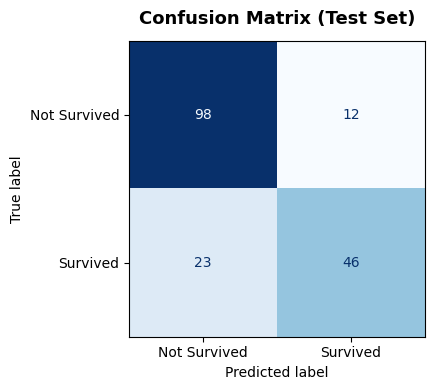

True Negatives  (Not Survived, predicted correctly): 98
False Positives (Not Survived, but predicted Survived): 12
False Negatives (Survived, but predicted Not Survived): 23
True Positives  (Survived, predicted correctly): 46


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    ax=ax,
    colorbar=False,
    display_labels=['Not Survived', 'Survived'],
    cmap='Blues'
)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Not Survived, predicted correctly): {tn}')
print(f'False Positives (Not Survived, but predicted Survived): {fp}')
print(f'False Negatives (Survived, but predicted Not Survived): {fn}')
print(f'True Positives  (Survived, predicted correctly): {tp}')

## Step 8 — ROC Curve

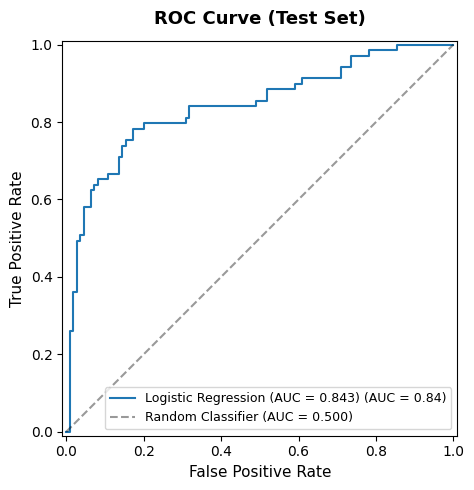

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    ax=ax,
    name=f'Logistic Regression (AUC = {roc_auc:.3f})'
)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier (AUC = 0.500)')
ax.set_title('ROC Curve (Test Set)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — 5-Fold Cross-Validation (ROC-AUC)

A single train/test split gives one performance estimate that is sensitive to which rows landed in the test set. **5-fold CV** splits the full dataset into 5 folds, trains on 4, evaluates on 1 — repeated 5 times. Reporting **mean ± std** gives a more honest, statistically stable estimate.

In [9]:
cv_auc = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print('5-Fold Cross-Validation — ROC-AUC')
print('-' * 40)
for i, score in enumerate(cv_auc, 1):
    print(f'  Fold {i}: {score:.4f}')
print('-' * 40)
print(f'  Mean : {cv_auc.mean():.4f}')
print(f'  Std  : {cv_auc.std():.4f}')
print(f'  95% CI ≈ [{cv_auc.mean() - 2*cv_auc.std():.4f}, {cv_auc.mean() + 2*cv_auc.std():.4f}]')

5-Fold Cross-Validation — ROC-AUC
----------------------------------------
  Fold 1: 0.8507
  Fold 2: 0.8297
  Fold 3: 0.8510
  Fold 4: 0.8388
  Fold 5: 0.8716
----------------------------------------
  Mean : 0.8484
  Std  : 0.0141
  95% CI ≈ [0.8202, 0.8765]


**Interpretation:**  
CV ROC-AUC of **0.848 ± 0.014** is very consistent across folds — the low std (< 0.02) confirms the model generalizes well and the result is not a lucky train/test split.

## Step 10 — Feature Importance (Coefficients)

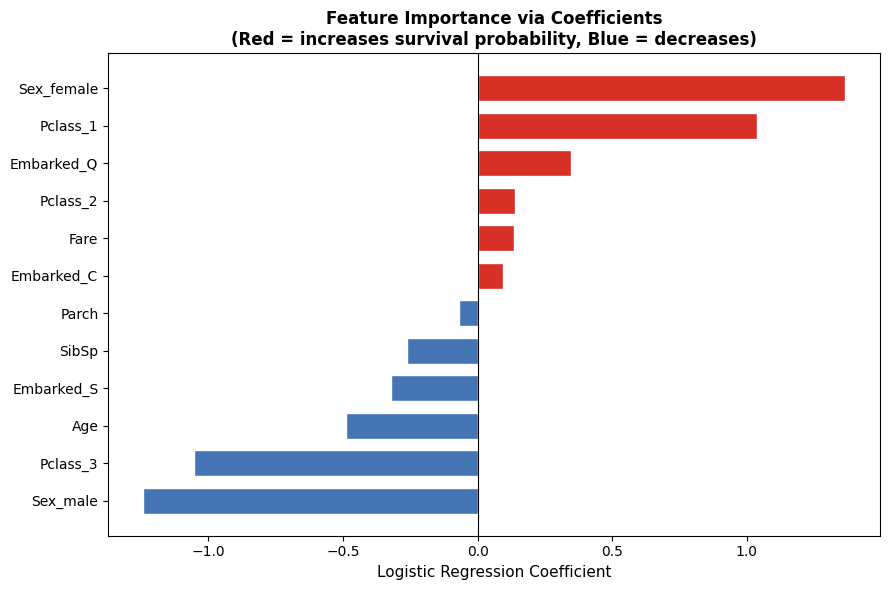


Top 5 survival-increasing features:
   Feature  Coefficient
      Fare     0.133851
  Pclass_2     0.138022
Embarked_Q     0.348068
  Pclass_1     1.038653
Sex_female     1.364351

Top 5 survival-decreasing features:
   Feature  Coefficient
  Sex_male    -1.242368
  Pclass_3    -1.054692
       Age    -0.489323
Embarked_S    -0.321817
     SibSp    -0.261398


In [10]:
# Extract feature names after OHE transformation
ohe_feature_names = (
    pipe.named_steps['prep']
    .named_transformers_['cat']['ohe']
    .get_feature_names_out(cat_cols)
)
all_feature_names = num_cols + list(ohe_feature_names)
coefs = pipe.named_steps['clf'].coef_[0]

fi_df = (
    pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
    .sort_values('Coefficient')
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d73027' if c > 0 else '#4575b4' for c in fi_df['Coefficient']]
ax.barh(fi_df['Feature'], fi_df['Coefficient'], color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient', fontsize=11)
ax.set_title('Feature Importance via Coefficients\n(Red = increases survival probability, Blue = decreases)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 survival-increasing features:')
print(fi_df.tail(5)[['Feature','Coefficient']].to_string(index=False))
print('\nTop 5 survival-decreasing features:')
print(fi_df.head(5)[['Feature','Coefficient']].to_string(index=False))

## Step 11 — Model Persistence (Save & Reload)

In [11]:
# Save the entire fitted pipeline
joblib.dump(pipe, 'model.joblib')
print(f'Model saved → model.joblib ({os.path.getsize("model.joblib"):,} bytes)')

# Reload and verify
loaded_model = joblib.load('model.joblib')
print('Model reloaded successfully ✅')

# Demo: predict on 5 test samples
print('\n--- Sample Predictions (5 test rows) ---')
sample = X_test.head(5).copy()
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]
actual = y_test.head(5).values

demo_df = sample.copy()
demo_df['Actual']     = ['Survived' if a == 1 else 'Not Survived' for a in actual]
demo_df['Predicted']  = ['Survived' if p == 1 else 'Not Survived' for p in preds]
demo_df['Prob(Surv)'] = probas.round(3)
demo_df['Correct?']   = ['✅' if a == p else '❌' for a, p in zip(actual, preds)]

display(demo_df[['Pclass','Sex','Age','Fare','Actual','Predicted','Prob(Surv)','Correct?']])

Model saved → model.joblib (4,730 bytes)
Model reloaded successfully ✅

--- Sample Predictions (5 test rows) ---


,Pclass,Sex,Age,Fare,Actual,Predicted,Prob(Surv),Correct?
565,3,male,24.0,24.1500,Not Survived,Not Survived,0.068,✅
160,3,male,44.0,16.1000,Not Survived,Not Survived,0.048,✅
553,3,male,22.0,7.2250,Survived,Not Survived,0.157,❌
860,3,male,41.0,14.1083,Not Survived,Not Survived,0.036,✅
241,3,female,NaN,15.5000,Survived,Survived,0.671,✅


## Step 12 — Final Report & Takeaways

---

### 📊 Performance Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | **80.4%** |
| Test ROC-AUC | **0.843** |
| 5-Fold CV ROC-AUC | **0.848 ± 0.014** |
| Precision (Survived) | **0.79** |
| Recall (Survived) | **0.67** |
| F1-score (Survived) | **0.72** |

---

### 🔍 Key Takeaways

1. **Sex is the most powerful predictor** — `Sex_female` shows the largest positive coefficient, confirming the historical "women and children first" evacuation policy.

2. **Passenger class strongly affects survival** — 3rd class passengers (`Pclass_3`) have the most negative coefficient; 1st class the most positive. This reflects both lifeboat proximity and evacuation priority.

3. **Age has a modest negative effect** — older passengers were slightly less likely to survive; however, its impact is weaker than Sex or Pclass.

4. **Fare is positively correlated with survival** — because it correlates with class and deck position (upper decks = closer to lifeboats).

5. **Embarked adds small signal** — passengers embarking at Cherbourg (C) had a slightly higher survival rate (more 1st class passengers boarded there).

6. **80% accuracy is strong for a linear baseline** — Logistic Regression with minimal features achieves this without any feature engineering or hyperparameter tuning.

7. **Low CV std (0.014) confirms generalization** — the model is not overfitting; consistent performance across all 5 folds.

8. **Class 1 (Survived) recall is lower (0.67)** — the model misses ~1 in 3 actual survivors. This is partly due to class imbalance (fewer survivors in training data).

9. **ROC-AUC 0.848 >> 0.5** — the model's probability ranking is much better than random. This makes it suitable as a baseline for downstream model comparison.

10. **The pipeline design prevents data leakage** — all imputation and scaling statistics are computed exclusively on training data and applied to the test set.

---

### ⚡ Strengths of This Baseline

- **Transparent and interpretable** — coefficients directly explain each feature's contribution
- **Fast to train** — < 1 second even on small hardware
- **Reproducible** — the full pipeline is serialized in a single `model.joblib` file
- **No data leakage** — ColumnTransformer + Pipeline architecture guarantees this

---

### 🚀 Limitations & Next Steps

| Limitation | Suggested Improvement |
|------------|----------------------|
| Linear decision boundary | Try **RandomForestClassifier** or **GradientBoosting** for non-linear patterns |
| No feature engineering | Add `FamilySize = SibSp + Parch`, `IsAlone`, extract `Title` from `Name` |
| Class imbalance ignored | Use `class_weight='balanced'` in Logistic Regression |
| No hyperparameter tuning | Apply `GridSearchCV` over `C`, `penalty`, `solver` |
| Cabin column discarded | Engineer a `HasCabin` binary feature — cabin presence correlates with class |
| No probability calibration | Use `CalibratedClassifierCV` if probability estimates need to be reliable |

In [12]:
# Final summary print
print('=' * 55)
print('           PIPELINE SUMMARY')
print('=' * 55)
print(f'  Features used     : {len(FEATURES)}')
print(f'  Training samples  : {X_train.shape[0]}')
print(f'  Test samples      : {X_test.shape[0]}')
print(f'  Test Accuracy     : {(y_pred == y_test).mean():.4f}')
print(f'  Test ROC-AUC      : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  CV ROC-AUC        : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')
print(f'  Model file        : model.joblib')
print(f'  Plots saved in    : images/')
print('=' * 55)
print('Pipeline complete! ✅')

           PIPELINE SUMMARY
  Features used     : 7
  Training samples  : 712
  Test samples      : 179
  Test Accuracy     : 0.8045
  Test ROC-AUC      : 0.8427
  CV ROC-AUC        : 0.848 ± 0.014
  Model file        : model.joblib
  Plots saved in    : images/
Pipeline complete! ✅
